In [1]:

import os
import sys
sys.path.append('/home/agustin/phd/synthesis')
sys.path.append('/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils')
import prep_image as prep_image

import utils.nifti_functions as nfc
import utils.functions as fc
import utils.util as util

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# import prep_images as prep_images
import prep_vol2vol as prep_vol2vol
import prep_image as prep_image


device_name = f"cuda:3"
device = torch.device(device_name)


In [2]:
# fixed = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/train_data/rawdata/T1W/0.1T/001_GX.nii.gz"
# moving = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/train_data/preprocessed/supersynth/T1W/0.1T/S001_GX/segmentation.nii.gz"
# output ="/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/__temp/001_GX_seg.nii.gz"
# license= "/home/agustin/licenses/fastsurfer.txt"
# prep_vol2vol.apply_vol2vol(fixed, moving, output,  verify=True, verbose=False, nearest=True)

(364, 436, 364)
(364, 436, 364)
lower vs current: 45875200 vs 57768256 (0.79x), diff: 11893056
upper vs current: 66060288 vs 57768256 (1.14x), diff: -8292032
upper vs lower: 66060288 vs 45875200 (0.69x), diff: 20185088
Latent lower vs current: 2867200.0 vs 3610516.0 (0.79x), diff: 743316.0
Latent upper vs current: 4128768.0 vs 3610516.0 (1.14x), diff: -518252.0
Latent upper vs lower: 4128768.0 vs 2867200.0 (0.69x), diff: 1261568.0


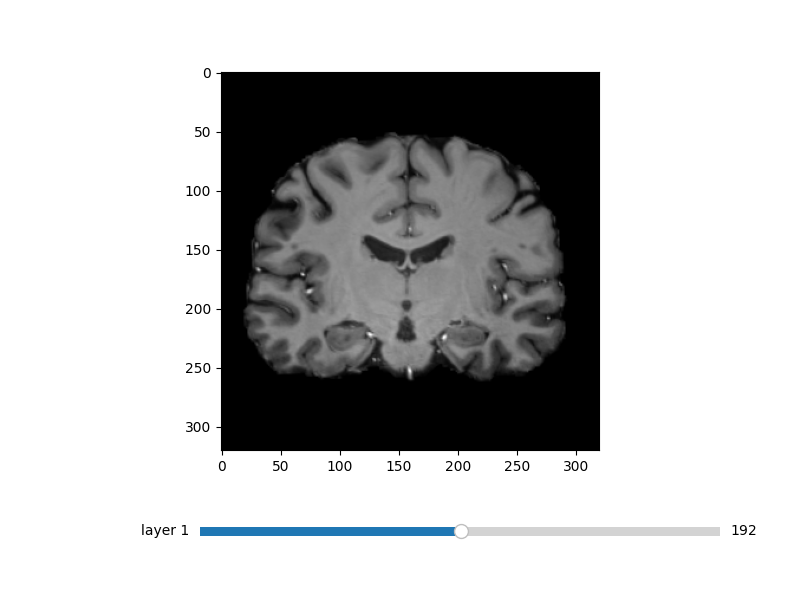

In [3]:
img, aff = nfc.load_nifti("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/zip/training/unzip/release_20260414/Training_retrospective/T1W/7T/R_T1W_7T_0822.nii.gz")
print(img.shape)
print(img.shape)

current_shape_space = np.prod(img.shape)
upper_target_shape_space = 384*448*384
# lower_target_shape_space = 320*384*320
lower_target_shape_space = 320*448*320



print(f"lower vs current: {lower_target_shape_space} vs {current_shape_space} ({lower_target_shape_space/current_shape_space:.2f}x), diff: {current_shape_space-lower_target_shape_space}")
print(f"upper vs current: {upper_target_shape_space} vs {current_shape_space} ({upper_target_shape_space/current_shape_space:.2f}x), diff: {current_shape_space-upper_target_shape_space}")
print(f"upper vs lower: {upper_target_shape_space} vs {lower_target_shape_space} ({lower_target_shape_space/upper_target_shape_space:.2f}x), diff: {upper_target_shape_space-lower_target_shape_space}")

latent_reduction_factor = 16
print(f"Latent lower vs current: {lower_target_shape_space/latent_reduction_factor} vs {current_shape_space/latent_reduction_factor} ({lower_target_shape_space/current_shape_space:.2f}x), diff: {(current_shape_space-lower_target_shape_space)/latent_reduction_factor}")
print(f"Latent upper vs current: {upper_target_shape_space/latent_reduction_factor} vs {current_shape_space/latent_reduction_factor} ({upper_target_shape_space/current_shape_space:.2f}x), diff: {(current_shape_space-upper_target_shape_space)/latent_reduction_factor}")
print(f"Latent upper vs lower: {upper_target_shape_space/latent_reduction_factor} vs {lower_target_shape_space/latent_reduction_factor} ({lower_target_shape_space/upper_target_shape_space:.2f}x), diff: {(upper_target_shape_space-lower_target_shape_space)/latent_reduction_factor}")


# print(384*448*384 - 320*384*320)

img = prep_image.prepare_img(img, desired_size=(320, 384, 320), normalize=True)

%matplotlib widget
fc.imgshow_3D(img, moving_plane=1)
# [364, 436, 364] # current shape
# (320, 384, 320) # lower target shape
# (384, 448, 384) # upper target shape   
# (320, 448, 320) # medium target shape   



(96, 112, 96)
[0 1 2 3]


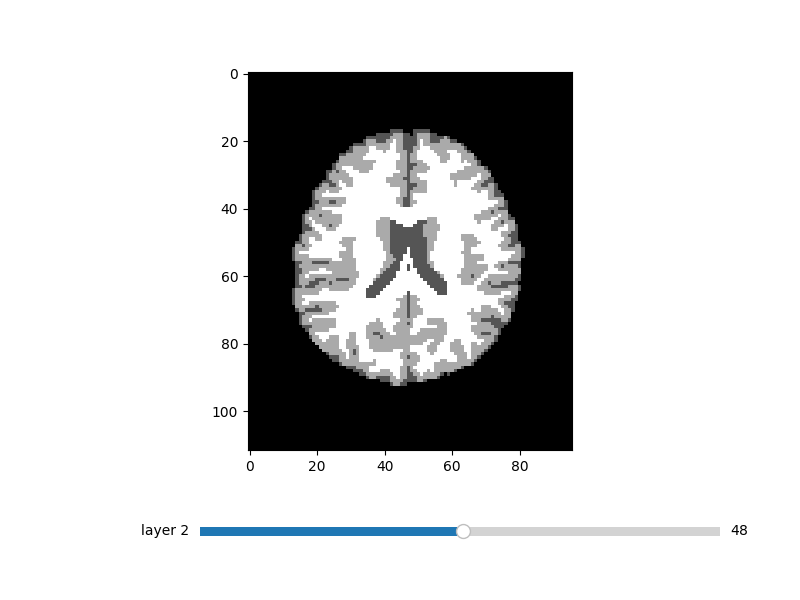

In [ ]:
seg = np.load("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/pr_train_data/preprocessed/latent_masks/merged_seg_3/T1W/0.1T/SP_T1W_0.1T_0006/segmentation.npy")
print(seg.shape)

print(np.unique(seg))

%matplotlib widget
fc.imgshow_3D(seg)

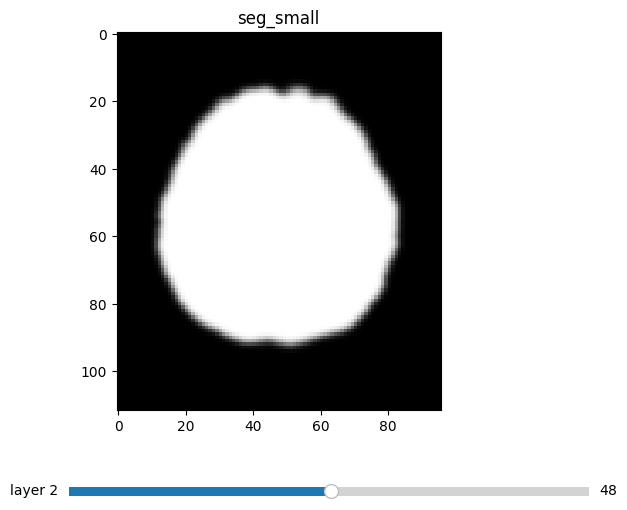

In [12]:
def prepare_img(img_path_name, normalize=True):
    img, aff = nfc.load_nifti(img_path_name)
    img, new_aff, aff = fc.resize_center_crop_pad(img, (384, 448, 384), aff)
    if normalize:
        img = util.robust_normalize(img, percentile=(0,100), strictly_positive=True)
    return img, aff



df_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv"
df = pd.read_csv(df_path)

modality = "T1W"
resolution = 7

df = df[(df["modality"] == modality) & (df["resolution"] == resolution)]
row = df.iloc[0]
seg, aff = nfc.load_nifti(row["segmentation_path"])
seg = prep_image.prepare_img(seg, normalize=False)
b_mask = np.where(seg > 0, 1, 0).astype(np.float32)
# make seg smaller by a factor of 4
from scipy.ndimage import zoom
seg_small = zoom(b_mask, (0.25, 0.25, 0.25), order=1)

# apply gaussian to be smoother
from scipy.ndimage import gaussian_filter
seg_small = gaussian_filter(seg_small, sigma=1)
# print(seg_small.shape)
# print(np.load(row["latent_path"]).shape)

fc.imgshow_3D(seg_small, name="seg_small", )